# Pandas 5 - Solutions

> **MLCourse · Data Science Foundations · 02_pandas**

Fully worked, commented solutions for `04_pandas_exercises.ipynb`.
Compare approach AND style - often several valid answers exist.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def load(name):
    try:
        import seaborn as sns
        return sns.load_dataset(name)
    except Exception as e:
        print(f"offline: {e}")
        return pd.DataFrame()

titanic = load("titanic")
tips    = load("tips")
mpg     = load("mpg")
flights = load("flights")

## Easy

### Task 1 - First look

In [2]:
print(titanic.tail(7))                                  # last 7 rows
print("shape:", titanic.shape)
print(titanic.dtypes)                                   # column dtypes at a glance
print(f"deep memory: {titanic.memory_usage(deep=True).sum()/1024:.0f} KB")
print("unique embark_town:", titanic["embark_town"].nunique())  # NaN excluded by default

     survived  pclass     sex   age  sibsp  parch    fare embarked   class  \
884         0       3    male  25.0      0      0   7.050        S   Third   
885         0       3  female  39.0      0      5  29.125        Q   Third   
886         0       2    male  27.0      0      0  13.000        S  Second   
887         1       1  female  19.0      0      0  30.000        S   First   
888         0       3  female   NaN      1      2  23.450        S   Third   
889         1       1    male  26.0      0      0  30.000        C   First   
890         0       3    male  32.0      0      0   7.750        Q   Third   

       who  adult_male deck  embark_town alive  alone  
884    man        True  NaN  Southampton    no   True  
885  woman       False  NaN   Queenstown    no  False  
886    man        True  NaN  Southampton    no   True  
887  woman       False    B  Southampton   yes   True  
888  woman       False  NaN  Southampton    no  False  
889    man        True    C    Cherbour

### Task 2 - Column surgery

In [3]:
slim = (
    titanic[["survived", "pclass", "sex", "age", "fare"]]  # 1. project columns
      .rename(columns={"fare": "ticket_price"})            # 2. rename one
      .dropna(subset=["sex"])                              # 3. filter rows
)
print(slim.shape, "- sex had no missing values here, so shape is unchanged.")

(891, 5) — sex had no missing values here, so shape is unchanged.


### Task 3 - loc vs iloc drill

In [4]:
# 1) positions 10..19 for labels sex..fare:
part_a = titanic.iloc[10:20].loc[:, "sex":"fare"]   # iloc picks ROWS positionally,
                                                    # then .loc slices columns by label.
# (Equivalent single-shot: titanic.loc[10:19, "sex":"fare"] works here only because
#  the default index happens to equal row positions - fragile in general!)

# 2) same cell, two ways:
cell_iloc = titanic.iat[100, titanic.columns.get_loc("fare")]  # iat = fast scalar iloc
cell_loc  = titanic.at[100, "fare"]                            # at  = fast scalar loc
print(cell_iloc, cell_loc, cell_iloc == cell_loc)

7.8958 7.8958 True


### Task 4 - Simple filters

In [5]:
big_dinner_tips = (
    tips.loc[
        (tips["time"] == "Dinner") & (tips["size"] >= 4) & (tips["tip"] > 3),
        ["total_bill", "tip", "size"],
    ]
)
print(len(big_dinner_tips), "rows match.")
big_dinner_tips.head()

24 rows match.


,total_bill,tip,size
4,24.59,3.61,4
5,25.29,4.71,4
7,26.88,3.12,4
11,35.26,5.00,4
23,39.42,7.58,4


> 💡 Note the parentheses around every condition - `&` binds tighter than
comparisons without them.

### Task 5 - Sorting

In [6]:
top5 = (
    mpg.sort_values("mpg", ascending=False, na_position="last")  # NaN sinks to bottom
       .loc[:, ["name", "mpg", "horsepower"]]
       .head(5)
)
top5

,name,mpg,horsepower
322,mazda glc,46.6,65.0
329,honda civic 1500 gl,44.6,67.0
325,vw rabbit c (diesel),44.3,48.0
394,vw pickup,44.0,52.0
326,vw dasher (diesel),43.4,48.0


## Medium

### Task 6 - Missing-data strategy design

In [7]:
# --- report ---------------------------------------------------------------
report = pd.DataFrame({
    "n_missing": titanic.isna().sum(),
    "pct_missing": (titanic.isna().mean() * 100).round(1),
}).query("n_missing > 0").sort_values("pct_missing", ascending=False)
print(report)

cleaned = titanic.copy()

# 1) DROP deck: ~77% missing -> imputation would fabricate most of the column;
#    the little signal it holds isn't worth it. Dropping the COLUMN not rows!
cleaned = cleaned.drop(columns="deck")

# 2) age -> median: age is right-skewed-ish with outliers; median is robust,
#    and we preserve every passenger record.
cleaned["age"] = cleaned["age"].fillna(cleaned["age"].median())

# 3) embarked/embark_town -> mode: categorical with just 2 missing cells -
#    mode ('S' / 'Southampton') is the least-surprising fill.
for col in ["embarked", "embark_town"]:
    cleaned[col] = cleaned[col].fillna(cleaned[col].mode()[0])

assert cleaned[["age", "embarked", "embark_town"]].isna().sum().sum() == 0
print("\nRemaining missing anywhere:", cleaned.isna().sum().sum(), "(should be 0)")

             n_missing  pct_missing
deck               688         77.2
age                177         19.9
embarked             2          0.2
embark_town          2          0.2

Remaining missing anywhere: 0 (should be 0)


### Task 7 - Named aggregation report

In [8]:
by_class = (
    titanic.groupby("class", observed=True)
           .agg(
               passengers=("survived", "size"),        # size counts rows incl. NaN survived? no - use any col
               survival_rate=("survived", "mean"),
               avg_fare=("fare", "mean"),
               median_age=("age", "median"),
           )
           .round({"survival_rate": 3, "avg_fare": 2})
)
by_class

,passengers,survival_rate,avg_fare,median_age
class,,,,
First,216,0.630,84.15,37.0
Second,184,0.473,20.66,29.0
Third,491,0.242,13.68,24.0


### Task 8 - Pivot & proportion crosstab

In [9]:
pivot = pd.pivot_table(
    tips, index="day", columns="smoker",
    values="total_bill", aggfunc="mean",
    margins=True, margins_name="All",          # totals on both axes
)
print(pivot.round(2))

ct = pd.crosstab(titanic["class"], titanic["survived"], normalize="index").round(3)
ct.columns = ["died_rate", "survived_rate"]
ct

smoker    Yes     No    All
day                        
Thur    19.19  17.11  17.68
Fri     16.81  18.42  17.15
Sat     21.28  19.66  20.44
Sun     24.12  20.51  21.41
All     20.76  19.19  19.79

,died_rate,survived_rate
class,,
First,0.370,0.630
Second,0.527,0.473
Third,0.758,0.242


### Task 9 - Merge with a lookup table

In [10]:
lookup = pd.DataFrame({"origin": ["usa", "japan", "europe"],
                       "hq_city": ["Detroit", "Tokyo", "Stuttgart"]})

merged = mpg.merge(lookup, on="origin", how="left")   # left keeps all cars even if key missing
hq_mpg = merged.groupby("hq_city")["mpg"].mean().round(2).sort_values()
print(hq_mpg)
merged[["name", "origin", "hq_city"]].head(3)

hq_city
Detroit      20.08
Stuttgart    27.89
Tokyo        30.45
Name: mpg, dtype: float64


,name,origin,hq_city
0,chevrolet chevelle malibu,usa,Detroit
1,buick skylark 320,usa,Detroit
2,plymouth satellite,usa,Detroit


### Task 10 - Reshape wide ⇄ long

In [11]:
wide = flights.pivot(index="year", columns="month", values="passengers")
print(wide.iloc[:3, :4])                      # peek: years down, months across

long_back = (
    wide.rename_axis("year")                    # keep the year label named
        .reset_index()                          # year back to a normal column
        .melt(id_vars="year", var_name="month", value_name="passengers")
)
same = long_back.merge(flights, on=["year", "month", "passengers"], how="outer", indicator=True)
print((same["_merge"] == "both").all(), "-> melted frame matches original")

month  Jan  Feb  Mar  Apr
year                     
1949   112  118  132  129
1950   115  126  141  135
1951   145  150  178  163
True -> melted frame matches original


### Task 11 - Time series basics on flights

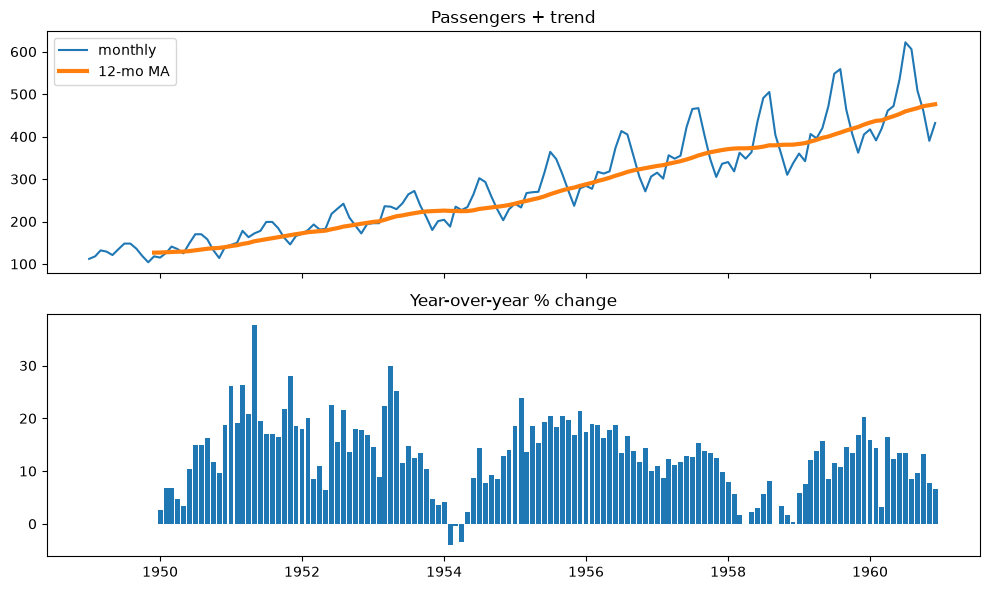

In [12]:
fts = (
    flights.assign(date=pd.to_datetime(flights["year"].astype(str)
                                       + "-" + flights["month"].astype(str) + "-01"))
             .set_index("date")
             .sort_index()["passengers"]
)

roll12 = fts.rolling(12).mean()
yoy_pct = fts.pct_change(12) * 100                 # vs same month last year

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(fts, label="monthly"); axes[0].plot(roll12, lw=3, label="12-mo MA")
axes[0].set_title("Passengers + trend"); axes[0].legend()
axes[1].bar(yoy_pct.index, yoy_pct.values, width=25)
axes[1].set_title("Year-over-year % change")
fig.tight_layout(); plt.show()

### Task 12 - Ordered categories

In [13]:
pclass_ordered = pd.Categorical(
    titanic["pclass"],
    categories=[3, 2, 1],          # TRUE social order: third < second < first
    ordered=True,
)
pc = pd.Series(pclass_ordered, name="pclass_ord")

print(pc.sort_values().head(3).tolist(), "-> smallest category first means class 3 first")
print(pd.Series(pc.sort_values().unique()).tolist())

mean_fare = titanic.assign(pc=pc).groupby("pc", observed=True)["fare"].mean().round(2)
print(mean_fare)

[3, 3, 3] -> smallest category first means class 3 first
[3, 2, 1]
pc
3    13.68
2    20.66
1    84.15
Name: fare, dtype: float64


### Task 13 - String extraction

In [14]:
mini = titanic.head(20).copy()
mini["email"] = "passenger" + mini.index.astype(str) + "@ship.com"   # build from index

extracted = mini["email"].str.extract(r"passenger(?P<pid>\d+)@")     # named capture group
mini["pid"] = extracted["pid"].astype(int)

print((mini["pid"] == mini.index).all(), "-> pid reconstructs the index exactly")

True -> pid reconstructs the index exactly


## Hard

### Task 14 - Top-n per group, two ways

In [15]:
way1 = (
    tips.sort_values("total_bill", ascending=False, kind="mergesort")
        .drop_duplicates(subset="day")            # first row per day = day's max
        [["day", "total_bill"]]
        .sort_values("day", kind="mergesort")     # stable sort -> deterministic order
)

way2 = (
    tips.sort_values("total_bill", ascending=False, kind="mergesort")
        .groupby("day", observed=True)
        .head(1)[["day", "total_bill"]]           # head(2) would give top-2 per group
        .sort_values("day", kind="mergesort")
)

pd.testing.assert_frame_equal(way1.reset_index(drop=True), way2.reset_index(drop=True))
print("identical ✓\n", way1)

identical ✓
       day  total_bill
197  Thur       43.11
95    Fri       40.17
170   Sat       50.81
156   Sun       48.17


> 💡 For n>1, `drop_duplicates` needs a rank helper; `groupby().head(n)` handles
it natively - that's why method 2 generalizes better.

### Task 15 - Binning + association

In [16]:
ages = titanic.dropna(subset=["age"]).copy()
ages["age_q"] = pd.qcut(ages["age"], q=4, labels=["Q1_youngest", "Q2", "Q3", "Q4_oldest"])

rate = pd.crosstab(ages["age_q"], ages["survived"], normalize="index")[1].rename("survived_rate")
print(rate.round(3))
best = rate.idxmax()
print(f"\nHighest survival: {best} ({rate.max():.1%})")
# Insight: children & young adults (Q1/Q2) survived most - 'women and children first'
# shows up directly in the numbers; elderly quartile fares worst.

age_q
Q1_youngest    0.458
Q2             0.361
Q3             0.434
Q4_oldest      0.373
Name: survived_rate, dtype: float64

Highest survival: Q1_youngest (45.8%)


### Task 16 - De-loop this code

In [17]:
# The ORIGINAL loop version (kept for comparison):
loop_out = {}
for s in titanic["sex"].unique():
    mask = (titanic["sex"] == s) & (titanic["survived"] == 1) & (titanic["age"] > 18)
    loop_out[s] = round(titanic.loc[mask, "fare"].mean(), 2)

out = (
    titanic.query("survived == 1 and age > 18")   # declarative filtering
           .groupby("sex", observed=True)["fare"]
           .mean()
           .round(2)
)
print("vectorized:", out.to_dict())
assert out.to_dict() == loop_out   # same numbers, zero loops

vectorized: {'female': 60.06, 'male': 46.36}
